INITIALISING ALL THE LIBRARIES


In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE 
from sklearn.decomposition import PCA
from sklearn.metrics import euclidean_distances
from scipy.spatial.distance import cdist
from matplotlib import pyplot as plt
from matplotlib.pyplot import plot
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

LOADING DATASETS


In [3]:
data= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/data.csv")
genre_data= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/data_by_genres.csv")
year_data= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/data_by_year.csv")
artist_data= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/data_by_artist.csv")

In [4]:
print(data.info())
print(genre_data.info())
print(year_data.info())
print(artist_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

HEATMAP REPRESENTATION


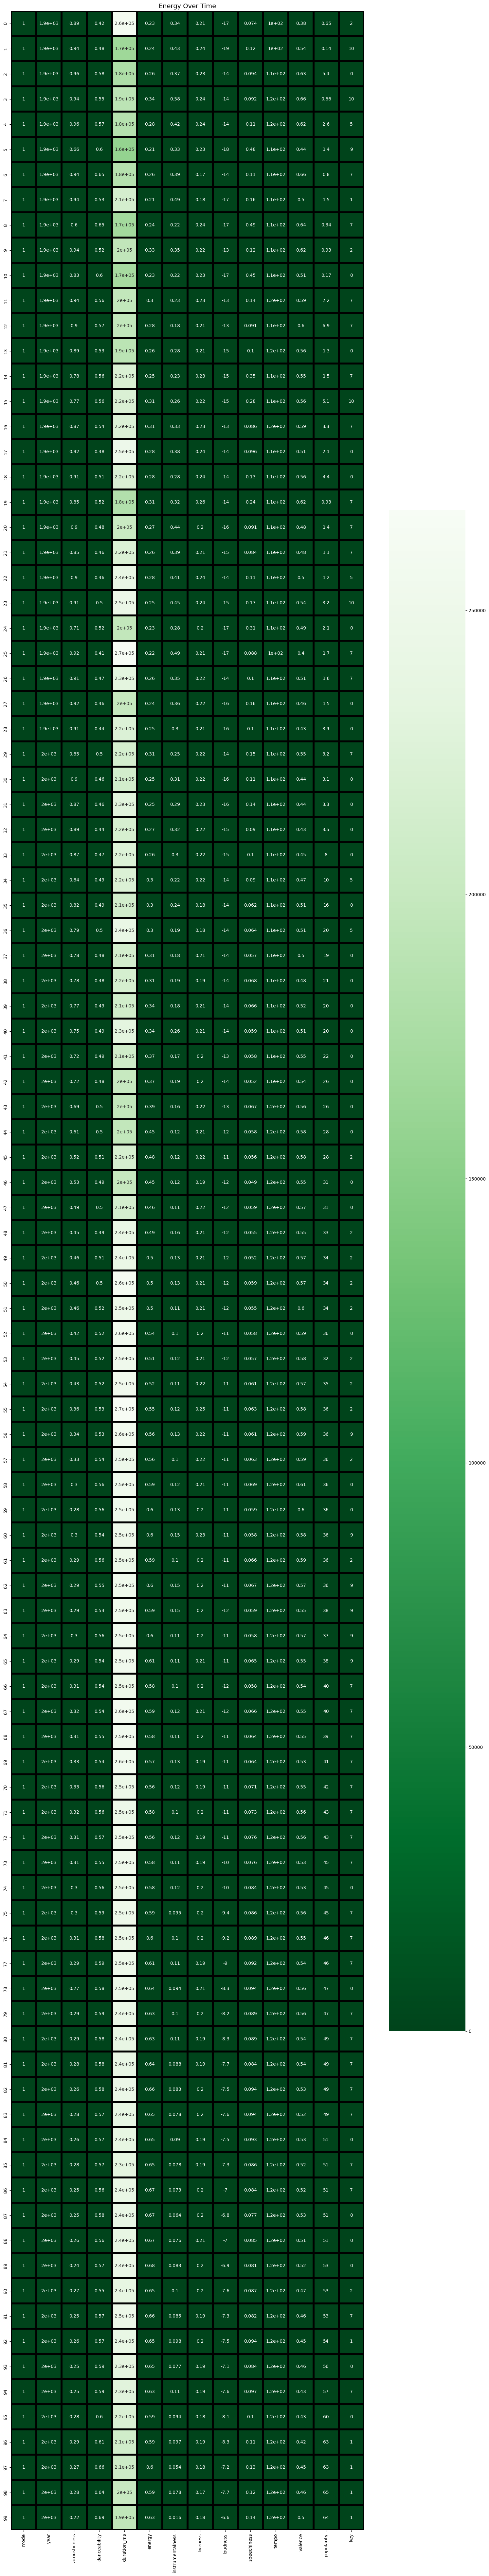

In [5]:
year_data.pivot(index='year', columns='duration_ms', values='energy').head()
plt.figure(figsize=(20, 100))
pivot_table = year_data.pivot(index='year', columns='duration_ms', values='energy')
plt.xlabel('year', size=14)
plt.ylabel('duration_ms', size=14)
plt.title('Energy Over Time', size=14)
sns.heatmap(year_data, annot=True, linewidths=4, linecolor='black', square=True, cmap='Greens_r', cbar=True);

In [6]:
df= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
numeric_df=df.select_dtypes(include=['float64','int64'])
corr=numeric_df.corr()
corr

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
Unnamed: 0,1.000000,0.032142,-0.032743,0.003444,-0.055994,-0.005520,-0.027307,0.005107,-0.084952,0.076840,-0.070286,0.033639,0.053111,-0.025824,-0.021115
popularity,0.032142,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.032743,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.003444,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,-0.055994,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.005520,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,-0.027307,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,0.005107,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.084952,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,0.076840,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138


PLOTING


Text(0.5, 0.98, '')

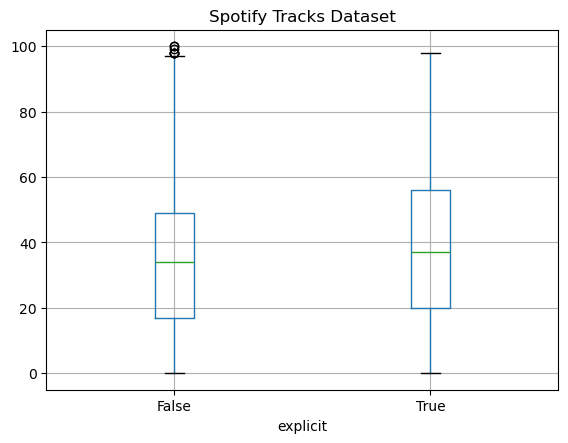

In [7]:
plot_df= pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
plot_df.head()
plot_df['explicit'].value_counts(dropna=False)
plot_df.boxplot(column='popularity', by='explicit')
plt.title('Spotify Tracks Dataset')
plt.suptitle('')

<Axes: xlabel='explicit', ylabel='popularity'>

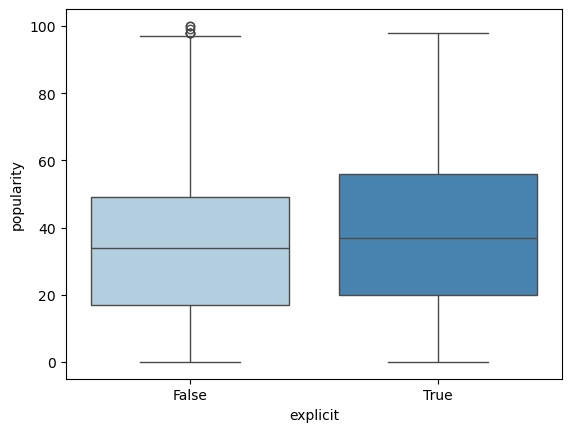

In [8]:
sns.boxplot(x='explicit', y='popularity', data=plot_df, palette='Blues')

FEATURE INDEPENDENCE PLOTS


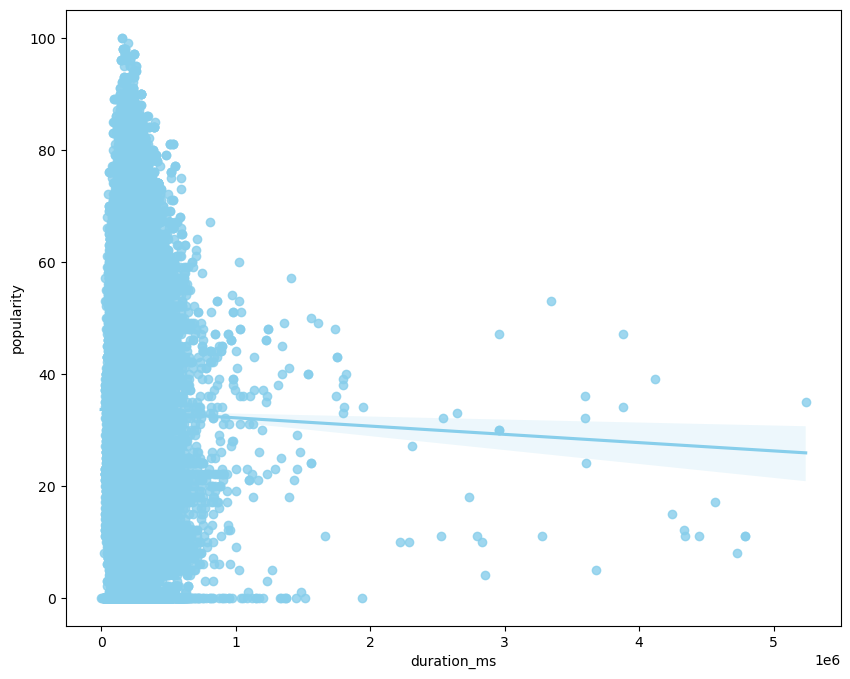

In [9]:
data=pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
x= data['duration_ms']
y= data['popularity']
plt.figure(figsize=(10,8))
sns.regplot(x=x, y=y, color="Skyblue", truncate=True)
plt.show()

OUTLIERS:- AN OUTLIER IS A DATA POINT WHIHC IS SIGNIFICANTLY FAR AWAY FROM OTHER DATA POINTS. THE INTER-QUARTILE RANGE (IQR) IS USED TO DETECT AND REMOVE OUTLIERS.


<Axes: xlabel='explicit', ylabel='popularity'>

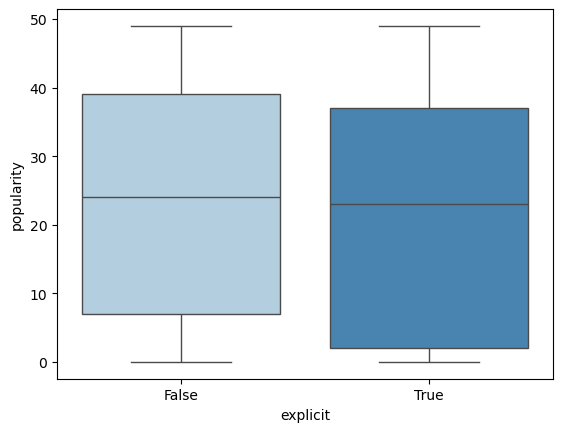

In [10]:
def outliers(df, ft):
    Q1= df[ft].quantile(0.25)
    Q3= df[ft].quantile(0.75)
    IQR= Q3-Q1
    lower_bond= Q1-1.5*IQR
    upper_bond= Q3= 1.5*IQR
    ls= df.index[(df[ft]<lower_bond)| (df[ft]>upper_bond)]
    return ls
index_list=[]
for feature in ['popularity']:
    index_list.extend(outliers(plot_df, feature))
def remove(df,ls):
    ls= sorted(set(ls))
    df= df.drop(ls)
    return df
cleaned_df= remove(plot_df, index_list)
sns.boxplot(x='explicit', y='popularity', data= cleaned_df, palette='Blues')

PATTERN OF INTERESTS


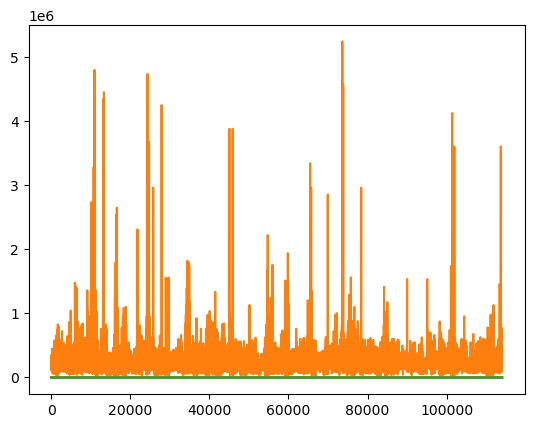

<Figure size 1000x1000 with 0 Axes>

In [11]:
data=pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
data.head()
data.columns
data= data[['popularity', 'duration_ms', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']]
data.head()
mean= np.mean(data)
std= np.std(data)
plt.plot(data)
plt.figure(figsize=(10,10))
plt.show()

TRENDS OF TIME AND SPACE


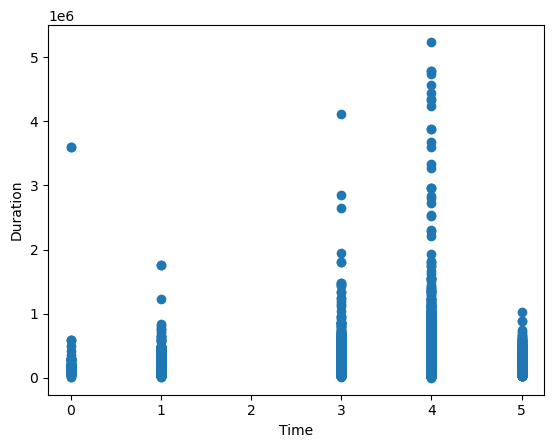

<Figure size 1000x1000 with 0 Axes>

In [12]:
data=pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
data=data[['time_signature', 'duration_ms']]
data=pd.DataFrame(data)

plt.scatter(df['time_signature'], df['duration_ms'])
plt.xlabel('Time')
plt.ylabel('Duration')
plt.figure(figsize=(10,10))
plt.show()

TRAIN, VALIDATION AND TEST


In [14]:
data=pd.read_csv("C:/Users/samar/OneDrive/Desktop/Programs/Personal-Project/Music-Recommendation-System/Datasets/dataset.csv")
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [15]:
train_data, val_and_test_data= train_test_split(data, test_size=0.3)
val_data, test_data=train_test_split(val_and_test_data, test_size=0.5)
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(79800, 21)
(17100, 21)
(17100, 21)


In [16]:
print(train_data.head())
print(val_data.head())
print(test_data.head())

       Unnamed: 0                track_id        artists  \
70987       70987  6oilrypHWm0iylwgX6ujQc         Mayday   
40351       40351  0C1DEVNH2WCyn6tfvvDdEy    Isaias Saad   
86415       86415  1FkoVC85Ds3mFoK0fVqEqP  The Offspring   
18701       18701  1Iw8clLu1c0IP2SbsBOV6I     Jeff Allen   
38039       38039  7JOIlJ9KSPIr8SRK4zl8zj    Royal Blood   

                     album_name     track_name  popularity  duration_ms  \
70987    知足 just my pride 最真傑作選             知足          46       256626   
40351              Espírito Vem   Espírito Vem          43       328330   
86415                     Smash    Self Esteem          77       257826   
18701     Three Word Vocabulary        Therapy          22        78480   
38039  Alternative Rock Mixtape  Figure It Out           0       184053   

       explicit  danceability  energy  ...  loudness  mode  speechiness  \
70987     False         0.519   0.232  ...    -9.029     1       0.0269   
40351     False         0.414   0.480 